# Data Cleaning

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

df = pd.read_csv('../data/euromillions.csv')

In [30]:
print(df.head())
print(df.info())

# date dataType
df['date (dd-mm-yyyy)'] = pd.to_datetime(df['date (dd-mm-yyyy)'], format='%d-%m-%Y')


# checking for duplicate date entries
print(df.duplicated().any())
# missing values
print(df.isnull().any())

  date (dd-mm-yyyy)  num_1  num_2  num_3  num_4  num_5  star_1  star_2  \
0        13-02-2004     16     29     32     36     41       7       9   
1        20-02-2004      7     13     39     47     50       2       5   
2        27-02-2004     14     18     19     31     37       4       5   
3        05-03-2004      4      7     33     37     39       1       5   
4        12-03-2004     15     24     28     44     47       4       5   

   jackpot (in EUR)  
0          15000000  
1          15000000  
2          17750473  
3          20678070  
4          15000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1932 entries, 0 to 1931
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date (dd-mm-yyyy)  1932 non-null   object
 1   num_1              1932 non-null   int64 
 2   num_2              1932 non-null   int64 
 3   num_3              1932 non-null   int64 
 4   num_4              1932 non-nu

In [31]:
# num1-5 should be between 1 and 50
num_columns = ['num_1', 'num_2', 'num_3', 'num_4', 'num_5']
for col in num_columns:
    if df[df[col] < 1].shape[0] or df[df[col] > 50].shape[0]:
        print(col)

# star 1-2 should be between 1 and 12
star_columns = ['star_1', 'star_2']
for col in star_columns:
    if df[df[col] < 1].shape[0] or df[df[col] > 12].shape[0]:
        print(col)

# Exploratory Data Analysis 

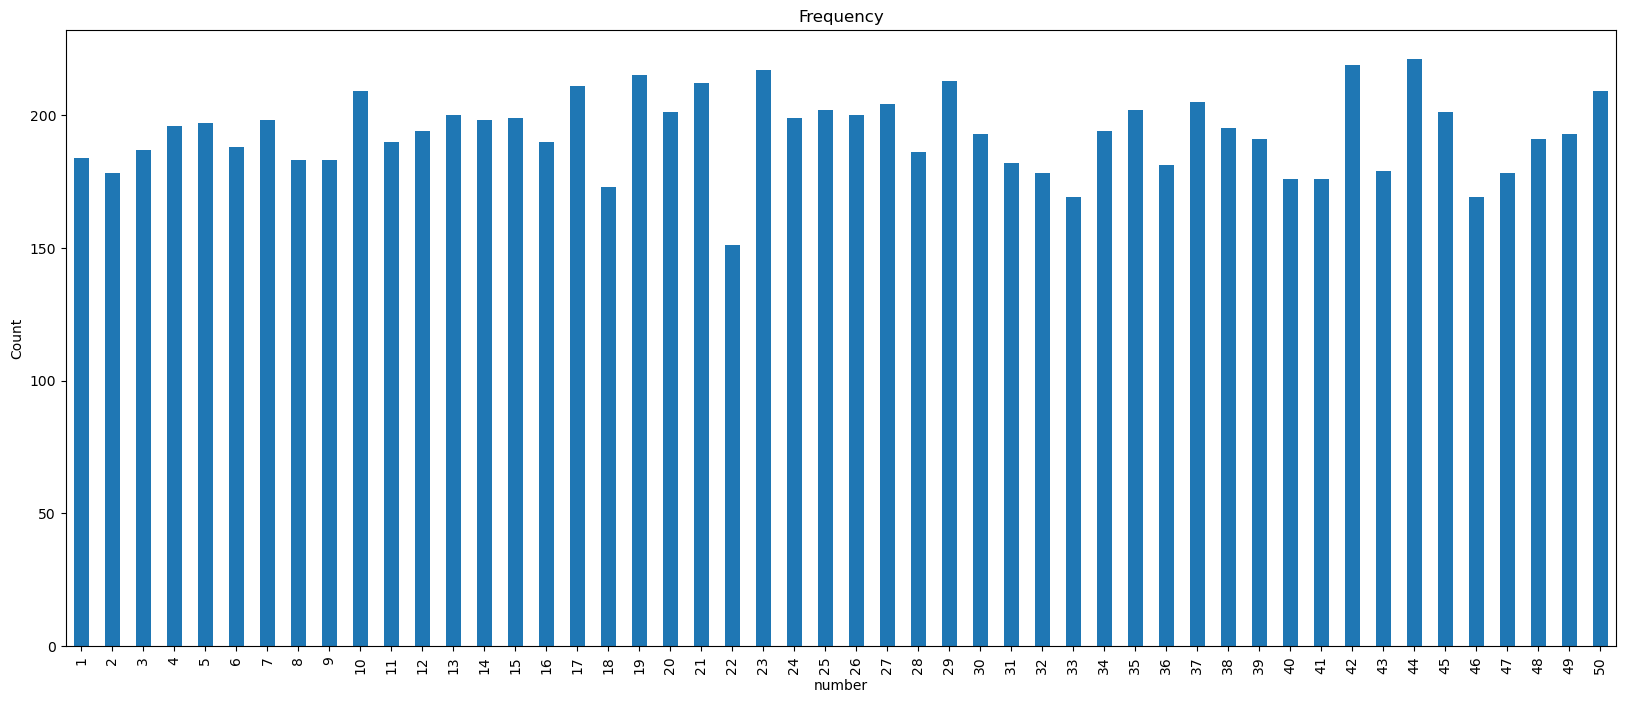

In [41]:
nums_all = pd.concat([df['num_1'], df['num_2'], df['num_3'], df['num_4'], df['num_5']])
nums_counts = nums_all.value_counts().sort_index()
# print('All numbers:\n', nums_counts)

nums_counts.plot(kind='bar', figsize=(20, 8))
plt.title('Frequency')
plt.xlabel('number')
plt.ylabel('Count')

plt.show()

nums_odd = []
nums_even = []
for number in nums_all:
    if number % 2 == 0:
        nums_even.append(number)
    else:
        nums_odd.append(number)
# print('Amount of Even Numbers: ', len(nums_even))
# print('Amount of Odd Numbers: ', len(nums_odd))

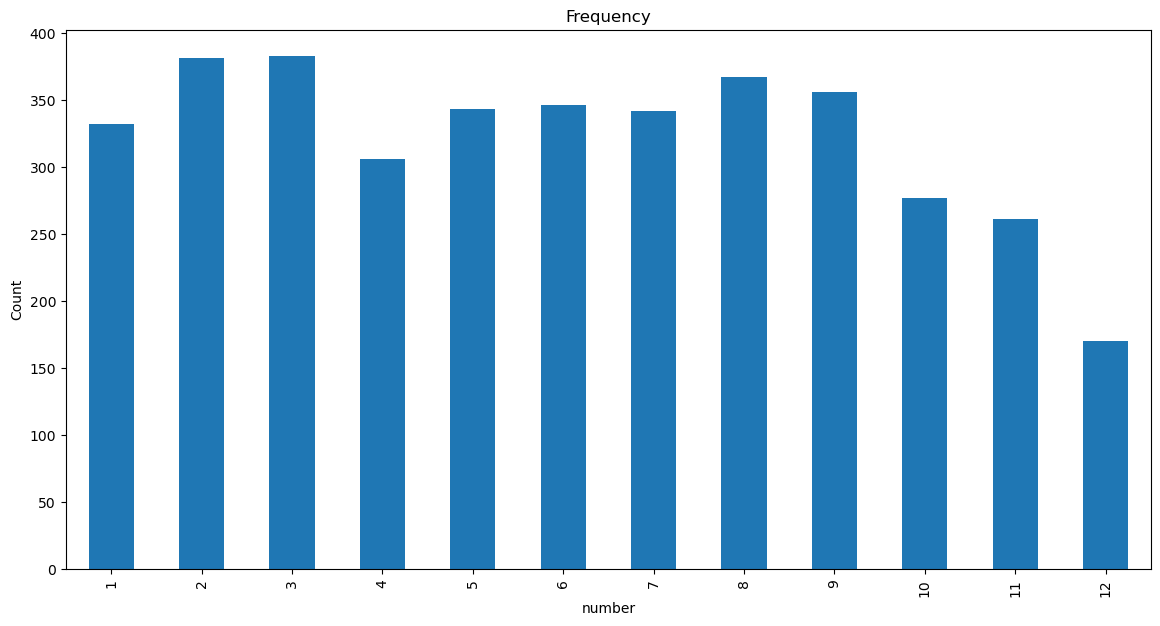

In [38]:
stars_all = pd.concat ([df['star_1'], df['star_2']])
stars_counts = stars_all.value_counts().sort_index()
# print('All star: \n', stars_counts)

stars_counts.plot(kind='bar', figsize=(14, 6))
plt.title('Frequency')
plt.xlabel('number')
plt.ylabel('Count')

plt.show()

In [36]:
print(df.describe())

                   date (dd-mm-yyyy)        num_1        num_2       num_3  \
count                           1932  1932.000000  1932.000000  1932.00000   
mean   2016-08-17 20:52:10.434782720     8.536232    16.895445    25.36853   
min              2004-02-13 00:00:00     1.000000     2.000000     4.00000   
25%              2012-05-10 06:00:00     3.000000    10.000000    19.00000   
50%              2016-12-25 00:00:00     7.000000    16.000000    25.00000   
75%              2021-08-10 18:00:00    12.000000    23.000000    32.00000   
max              2026-03-27 00:00:00    38.000000    44.000000    47.00000   
std                              NaN     6.611998     8.213518     8.77333   

             num_4        num_5       star_1       star_2  jackpot (in EUR)  
count  1932.000000  1932.000000  1932.000000  1932.000000      1.932000e+03  
mean     34.071946    42.641304     4.002588     8.146998      5.642283e+07  
min       9.000000    16.000000     1.000000     2.000000      